In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

In [ ]:
import os
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [91]:
np.random.seed(42)

T = 500
print(f"T:{T}\n")

rho = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])
print(f"rho: {rho}\n sigma:{sigma}\n")

P = np.array(
    [[0.95, 0.05],
    [0.05, 0.95]]
    )
print(f"P: {P}\n")

states = np.zeros(T, dtype=int)
y = np.zeros(T)
# print(f"states: {states}\n y: {y}\n")

states[0] = np.random.choice([0,1])
y[0] = np.random.normal()
print(f"states[0]: {states[0]}\n y[0]: {y[0]}\n")

for t in range(1, T):
    states[t] = np.random.choice([0,1], p=P[states[t-1]])
    s = states[t]
    y[t] = rho[s]*y[t-1] + np.random.normal(scale=sigma[s])

    if t % 50 == 0:
        col1 = f"iteration {t}"
        col2 = f"state: {s}"
        col3 = f"y[{t}]: {y[t]:.4f}"
        print(f"{col1:<20s}{col2:<15s}{col3}")


T:500

rho: [0.2 0.8]
 sigma:[0.5 1. ]

P: [[0.95 0.05]
 [0.05 0.95]]

states[0]: 0
 y[0]: -0.5502344891639495

iteration 50        state: 0       y[50]: -0.1451
iteration 100       state: 1       y[100]: 2.1131
iteration 150       state: 0       y[150]: 1.6434
iteration 200       state: 1       y[200]: 0.6728
iteration 250       state: 1       y[250]: 0.5355
iteration 300       state: 0       y[300]: 0.0844
iteration 350       state: 0       y[350]: 0.4408
iteration 400       state: 1       y[400]: 1.8351
iteration 450       state: 0       y[450]: -0.3329


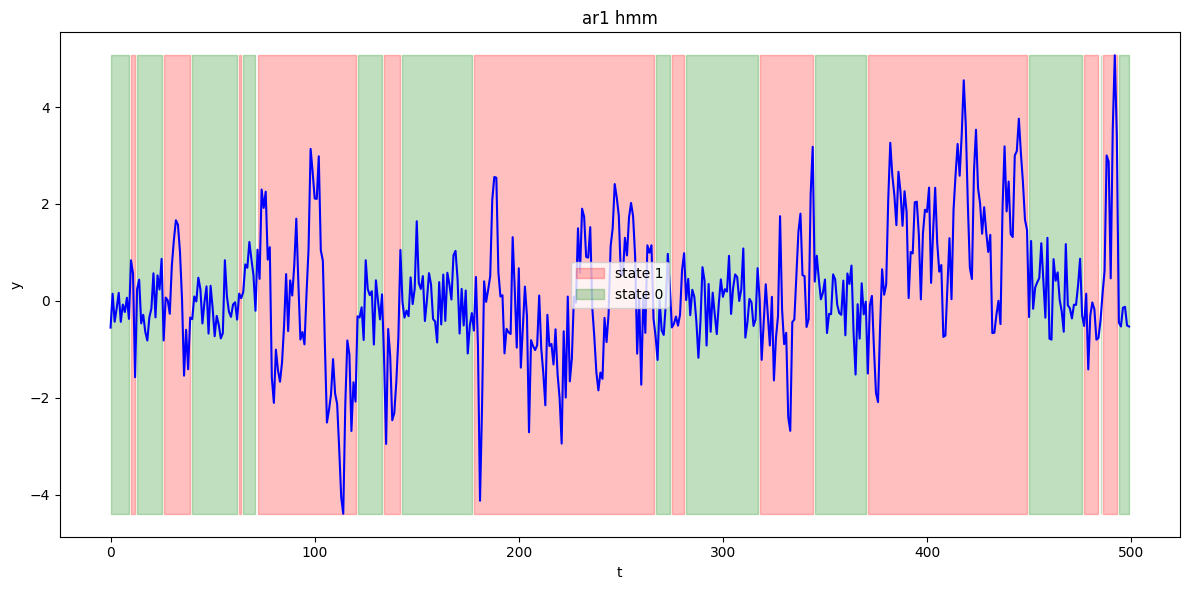

In [92]:
plt.figure(figsize=(12,6))
plt.plot(y, color="blue")
plt.fill_between(range(T), y.min(), y.max(), where=(states==1), alpha=0.25, color="red", label="state 1")
plt.fill_between(range(T), y.min(), y.max(), where=(states==0), alpha=0.25, color="green", label="state 0")
plt.title("ar1 hmm")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ar1_hmm_simulated_path.pdf"), bbox_inches="tight")
plt.show()

In [93]:
def ark(T, k, rho, sigma, P):

    assert len(rho) == k, f"Error rho length must be equal to {k} length"
    assert len(sigma) == k, f"Error sigma length must be equal to {k} length"
    assert P.shape == (k, k), f"Error P must be a {k}x{k} matrix"
    assert np.allclose(P.sum(axis=1), 1), "Error every row in transition matrix P must sum to 1.0"

    states = np.zeros(T, dtype=int)
    y = np.zeros(T)

    states[0] = np.random.choice(k)
    y[0] = np.random.normal()

    for t in range(1, T):
        states[t] = np.random.choice(k, p=P[states[t-1]])
        s = states[t]
        y[t] = rho[s] * y[t-1] + np.random.normal(scale=sigma[s])

    return states, y

In [94]:
np.random.seed(42)

T = 500
k = 4

rho_params = np.random.uniform(-0.8, 0.8, k)
sigma_params = np.random.uniform(0.5, 2.0, k)

print(f"rho_params: {rho_params}")
print(f"sigma_params: {sigma_params}")

P_matrix = np.random.dirichlet(np.ones(k), size=k)

simulated_states, simulated_y = ark(T, k, rho_params, sigma_params, P_matrix)

print(f"simulated {T} steps for {k} states")
print(f"first 5 states: {simulated_states[:5]}")
print(f"first 5 y values: {np.round(simulated_y[:5], 4)}")
print(f"\n")

rho_params: [-0.20073581  0.72114289  0.37119031  0.15785357]
sigma_params: [0.73402796 0.73399178 0.58712542 1.79926422]
simulated 500 steps for 4 states
first 5 states: [1 0 3 2 1]
first 5 y values: [ 0.2221 -0.6083  1.945   0.6604 -1.0113]




C:\Users\ofurn\AppData\Local\Temp\ipykernel_23216\3797273232.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


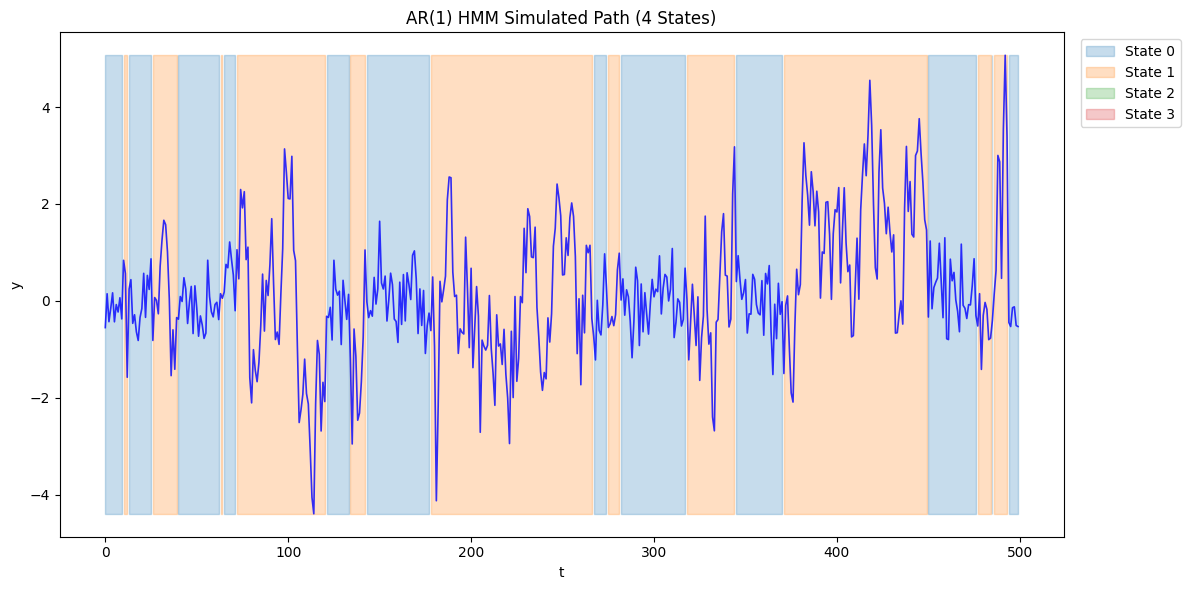

In [95]:
plt.figure(figsize=(12,6))
plt.plot(y, color="blue", linewidth=1.2, alpha=0.8)
cmap = plt.cm.get_cmap('tab10')

for i in range(k):
    plt.fill_between(
        range(T), 
        y.min(), 
        y.max(), 
        where=(states == i), 
        alpha=0.25, 
        color=cmap(i), 
        label=f"State {i}"
    )

plt.title(f"AR(1) HMM Simulated Path ({k} States)")
plt.xlabel("t")
plt.ylabel("y")

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

plt.savefig(os.path.join(plot_dir, f"ar1_hmm_{k}_states.pdf"), bbox_inches="tight")

plt.show()

C:\Users\ofurn\AppData\Local\Temp\ipykernel_23216\3114822894.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


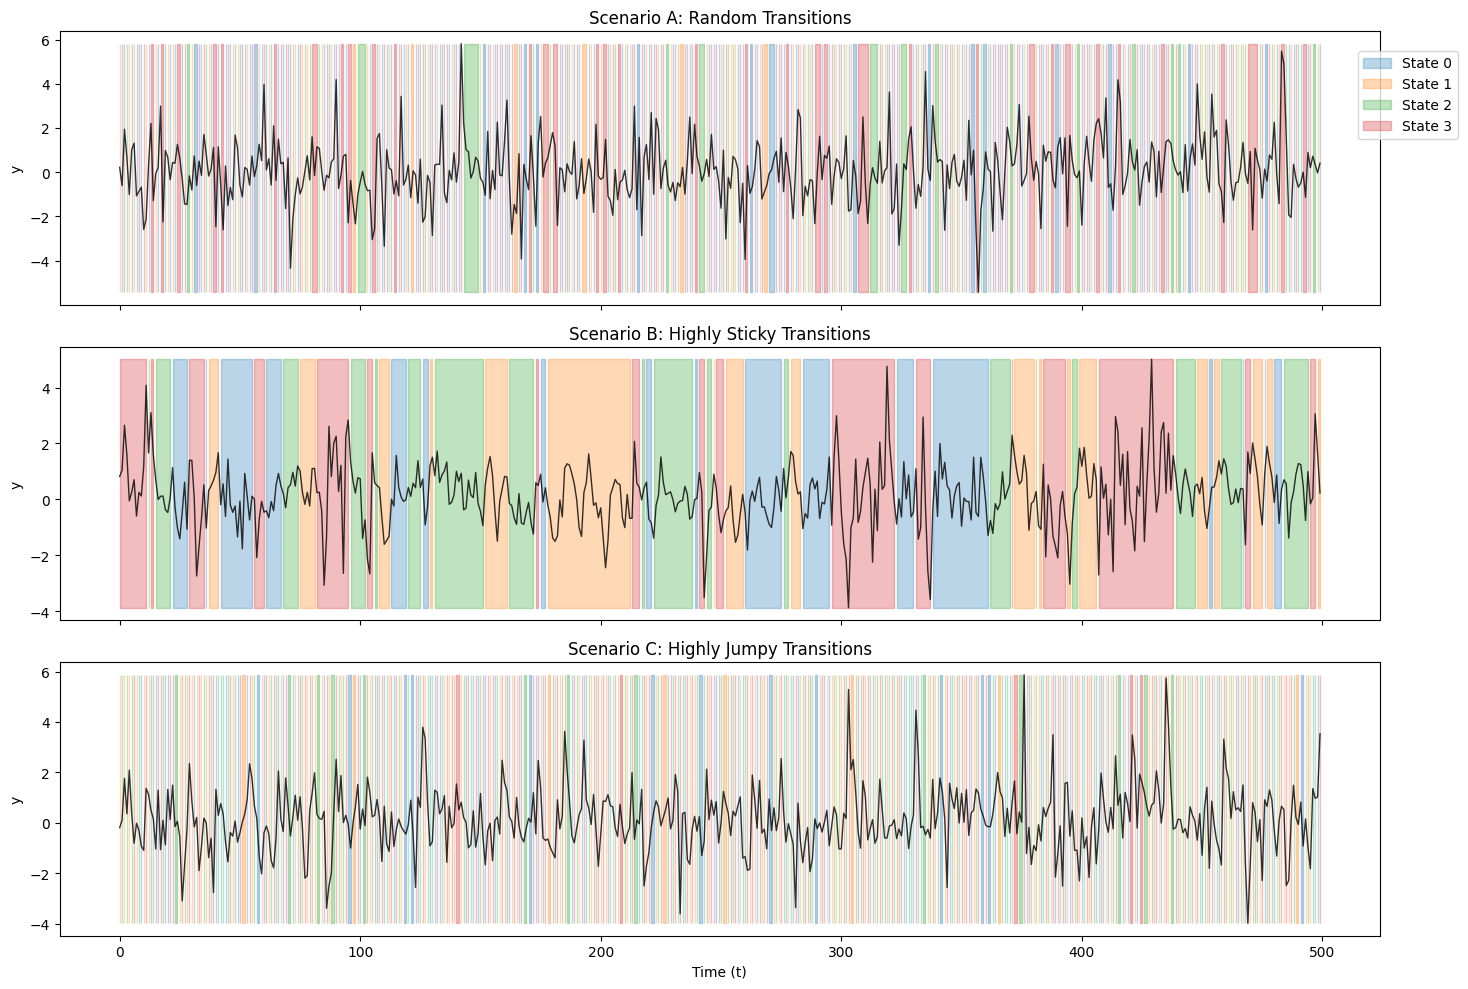

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# Your exact function!
def ark(T, k, rho, sigma, P):
    assert len(rho) == k, f"Error rho length must be equal to {k} length"
    assert len(sigma) == k, f"Error sigma length must be equal to {k} length"
    assert P.shape == (k, k), f"Error P must be a {k}x{k} matrix"
    assert np.allclose(P.sum(axis=1), 1), "Error every row in transition matrix P must sum to 1.0"

    states = np.zeros(T, dtype=int)
    y = np.zeros(T)

    states[0] = np.random.choice(k)
    y[0] = np.random.normal()

    for t in range(1, T):
        states[t] = np.random.choice(k, p=P[states[t-1]])
        s = states[t]
        y[t] = rho[s] * y[t-1] + np.random.normal(scale=sigma[s])

    return states, y

# --- 1. SIMULATE ALL DATA AT THE FRONT ---
np.random.seed(42)
T = 500
k = 4

rho_params = np.random.uniform(-0.8, 0.8, k)
sigma_params = np.random.uniform(0.5, 2.0, k)

# Scenario A: Random Transition Matrix
P_random = np.random.dirichlet(np.ones(k), size=k)
states_A, y_A = ark(T, k, rho_params, sigma_params, P_random)

# Scenario B: "Sticky" Transition Matrix (High probability on the diagonal)
P_sticky = np.array([
    [0.85, 0.05, 0.05, 0.05],
    [0.05, 0.85, 0.05, 0.05],
    [0.05, 0.05, 0.85, 0.05],
    [0.05, 0.05, 0.05, 0.85]
])
states_B, y_B = ark(T, k, rho_params, sigma_params, P_sticky)

# Scenario C: "Jumpy" Transition Matrix (Low probability on the diagonal)
P_jumpy = np.array([
    [0.10, 0.30, 0.30, 0.30],
    [0.30, 0.10, 0.30, 0.30],
    [0.30, 0.30, 0.10, 0.30],
    [0.30, 0.30, 0.30, 0.10]
])
states_C, y_C = ark(T, k, rho_params, sigma_params, P_jumpy)


# --- 2. PLOT THE DATA ---
# Create 3 subplots stacked vertically that share the same x-axis
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
cmap = plt.cm.get_cmap('tab10')

# Pack our scenarios into a list so we can loop through them easily
scenarios = [
    (y_A, states_A, "Scenario A: Random Transitions"),
    (y_B, states_B, "Scenario B: Highly Sticky Transitions"),
    (y_C, states_C, "Scenario C: Highly Jumpy Transitions")
]

for ax_idx, (y_data, state_data, title) in enumerate(scenarios):
    ax = axes[ax_idx]
    
    # Plot the time series
    ax.plot(y_data, color="black", linewidth=1.0, alpha=0.8)
    
    # Shade the background based on the state
    for i in range(k):
        ax.fill_between(
            range(T), 
            y_data.min(), 
            y_data.max(), 
            where=(state_data == i), 
            alpha=0.3, 
            color=cmap(i), 
            label=f"State {i}" if ax_idx == 0 else "" # Only label once for the legend
        )
    
    ax.set_title(title)
    ax.set_ylabel("y")

# Add a single legend for the whole figure
fig.legend(loc='upper right', bbox_to_anchor=(1.05, 0.95))
plt.xlabel("Time (t)")
plt.tight_layout()
plt.show()

C:\Users\ofurn\AppData\Local\Temp\ipykernel_23216\3967025402.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_data = plt.cm.get_cmap('tab10')


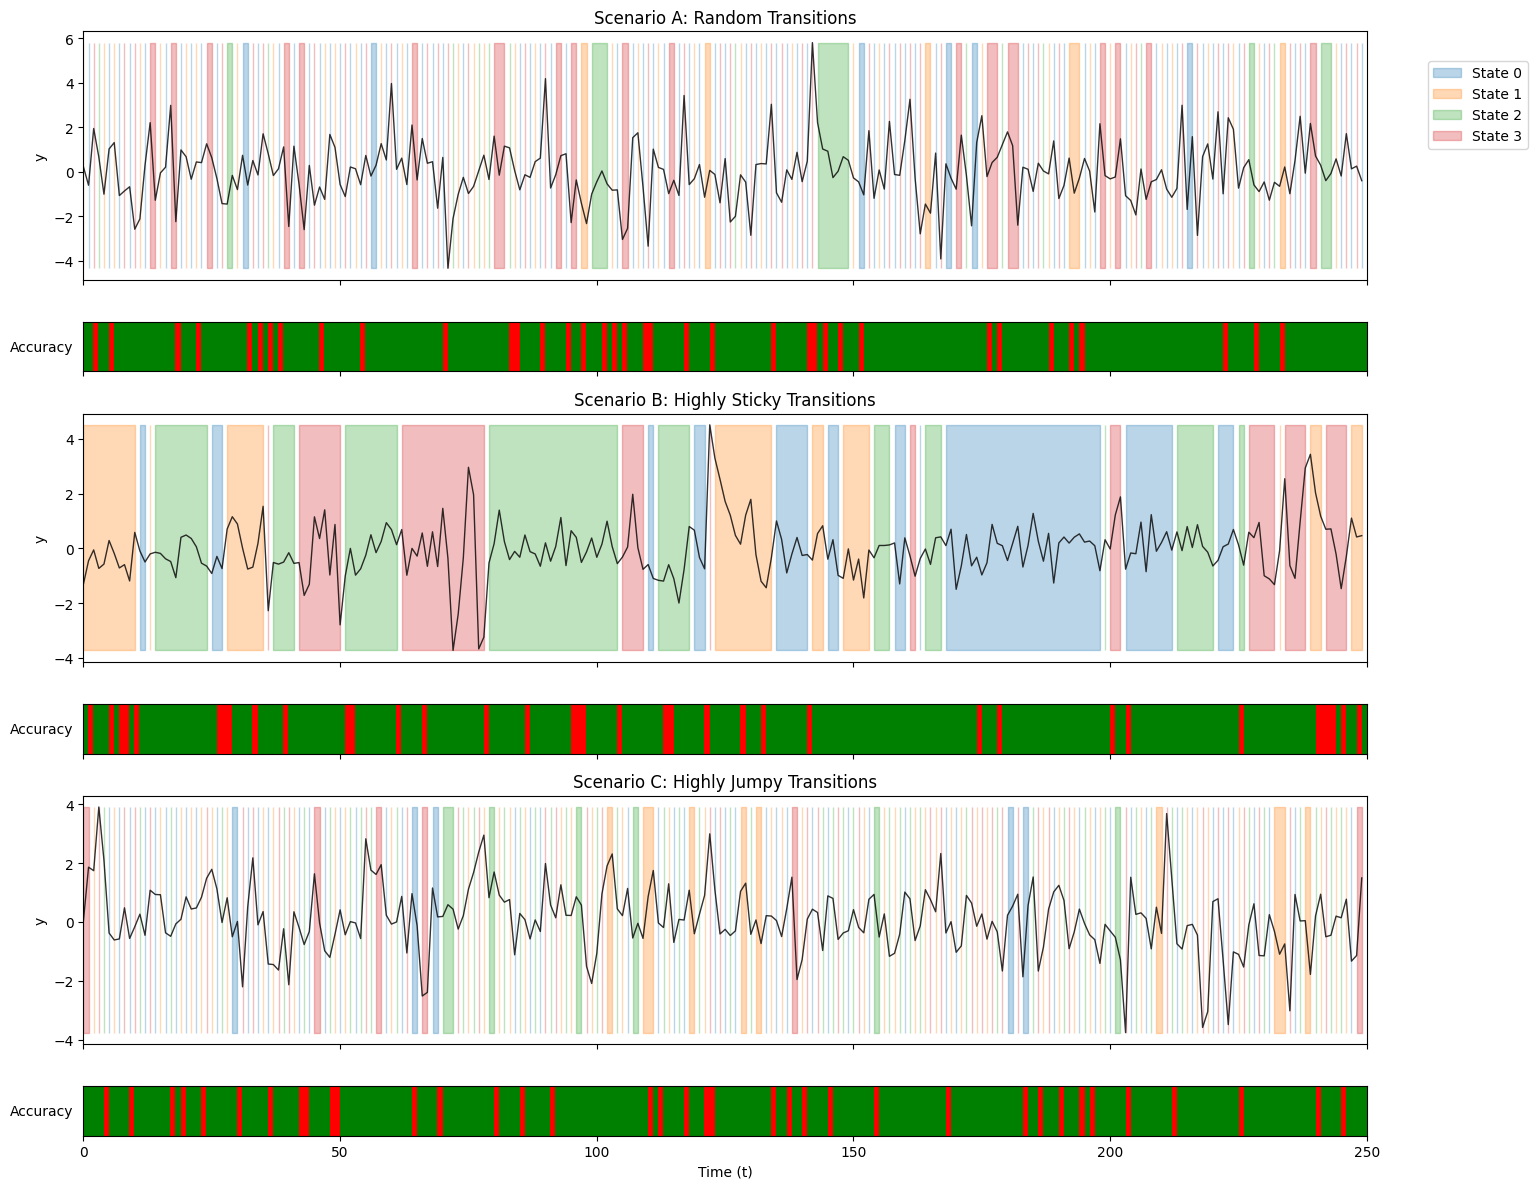

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Your exact simulation function
def ark(T, k, rho, sigma, P):
    assert len(rho) == k, f"Error rho length must be equal to {k} length"
    assert len(sigma) == k, f"Error sigma length must be equal to {k} length"
    assert P.shape == (k, k), f"Error P must be a {k}x{k} matrix"
    assert np.allclose(P.sum(axis=1), 1), "Error every row in transition matrix P must sum to 1.0"

    states = np.zeros(T, dtype=int)
    y = np.zeros(T)

    states[0] = np.random.choice(k)
    y[0] = np.random.normal()

    for t in range(1, T):
        states[t] = np.random.choice(k, p=P[states[t-1]])
        s = states[t]
        y[t] = rho[s] * y[t-1] + np.random.normal(scale=sigma[s])

    return states, y

# --- 1. SIMULATE ALL DATA AT THE FRONT ---
np.random.seed(42)
T = 250
k = 4

rho_params = np.random.uniform(-0.8, 0.8, k)
sigma_params = np.random.uniform(0.5, 2.0, k)

# Scenario A: Random
P_random = np.random.dirichlet(np.ones(k), size=k)
states_A, y_A = ark(T, k, rho_params, sigma_params, P_random)

# Scenario B: Sticky
P_sticky = np.array([
    [0.85, 0.05, 0.05, 0.05],
    [0.05, 0.85, 0.05, 0.05],
    [0.05, 0.05, 0.85, 0.05],
    [0.05, 0.05, 0.05, 0.85]
])
states_B, y_B = ark(T, k, rho_params, sigma_params, P_sticky)

# Scenario C: Jumpy
P_jumpy = np.array([
    [0.10, 0.30, 0.30, 0.30],
    [0.30, 0.10, 0.30, 0.30],
    [0.30, 0.30, 0.10, 0.30],
    [0.30, 0.30, 0.30, 0.10]
])
states_C, y_C = ark(T, k, rho_params, sigma_params, P_jumpy)


# --- 2. GENERATE MOCK PREDICTIONS ---
def get_mock_predictions(true_states, error_rate=0.15):
    """Creates fake predictions by randomly flipping a percentage of the true states."""
    pred = true_states.copy()
    error_indices = np.random.choice(len(true_states), size=int(error_rate * len(true_states)), replace=False)
    pred[error_indices] = (pred[error_indices] + np.random.randint(1, k, size=len(error_indices))) % k
    return pred

pred_A = get_mock_predictions(states_A)
pred_B = get_mock_predictions(states_B)
pred_C = get_mock_predictions(states_C)


# --- 3. PLOT THE DATA AND ACCURACY BARS ---
# Create 6 subplots: alternating tall (data) and short (accuracy)
fig, axes = plt.subplots(
    6, 1, 
    figsize=(14, 12), 
    sharex=True, 
    gridspec_kw={'height_ratios': [5, 1, 5, 1, 5, 1]} # Tall, Short, Tall, Short, Tall, Short
)

cmap_data = plt.cm.get_cmap('tab10')
cmap_accuracy = ListedColormap(['red', 'green']) # 0 = wrong, 1 = correct

scenarios = [
    (y_A, states_A, pred_A, "Scenario A: Random Transitions"),
    (y_B, states_B, pred_B, "Scenario B: Highly Sticky Transitions"),
    (y_C, states_C, pred_C, "Scenario C: Highly Jumpy Transitions")
]

for idx, (y_data, true_states, pred_states, title) in enumerate(scenarios):
    # Calculate the array indices for the data plot and accuracy plot
    ax_data = axes[idx * 2]       # 0, 2, 4
    ax_acc = axes[idx * 2 + 1]    # 1, 3, 5
    
    # --- Plot the Time Series (Top axis for this scenario) ---
    ax_data.plot(y_data, color="black", linewidth=1.0, alpha=0.8)
    for i in range(k):
        ax_data.fill_between(
            range(T), y_data.min(), y_data.max(), where=(true_states == i), 
            alpha=0.3, color=cmap_data(i), 
            label=f"State {i}" if idx == 0 else ""
        )
    ax_data.set_title(title)
    ax_data.set_ylabel("y")
    
    # --- Plot the Accuracy Bar (Bottom axis for this scenario) ---
    is_correct = (true_states == pred_states).astype(int)
    ax_acc.imshow(is_correct[np.newaxis, :], cmap=cmap_accuracy, aspect='auto', extent=[0, T, 0, 1])
    ax_acc.set_yticks([]) # Hide the y-axis ticks
    ax_acc.set_ylabel("Accuracy", rotation=0, labelpad=30, verticalalignment='center')

# Wrap up the figure formatting
fig.legend(loc='upper right', bbox_to_anchor=(1.1, 0.95))
plt.xlabel("Time (t)")
plt.tight_layout()
plt.show()

RMSE - Single AR(1): 1.3121
RMSE - Hard Switch:  1.3202
RMSE - Soft Switch:  1.3199


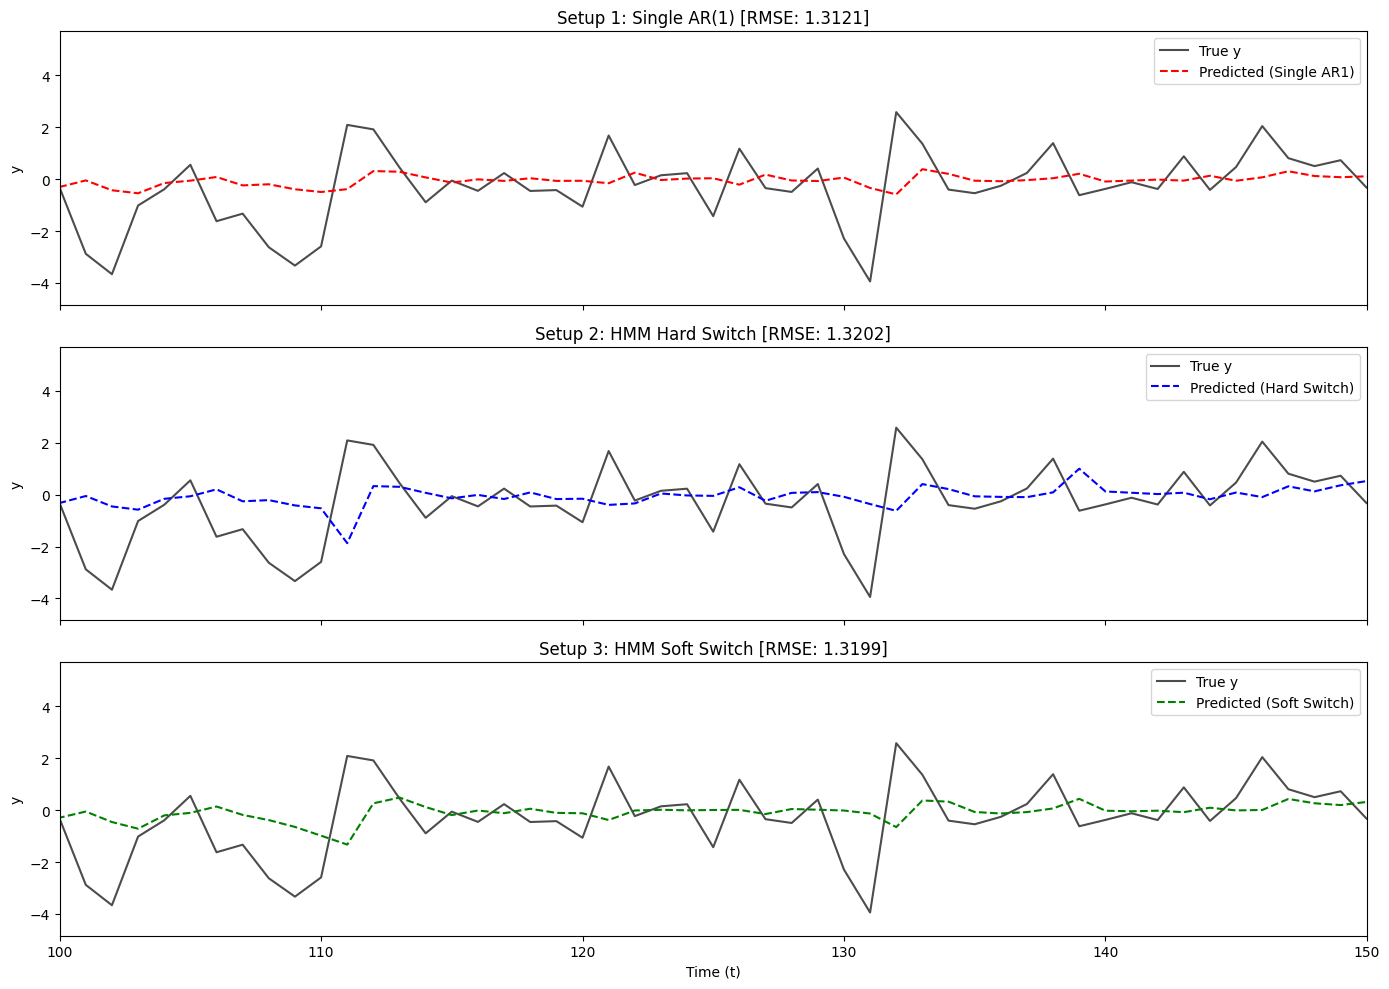

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. PREVIOUS FUNCTIONS ---
def ark(T, k, rho, sigma, P):
    states = np.zeros(T, dtype=int)
    y = np.zeros(T)
    states[0] = np.random.choice(k)
    y[0] = np.random.normal()
    for t in range(1, T):
        states[t] = np.random.choice(k, p=P[states[t-1]])
        y[t] = rho[states[t]] * y[t-1] + np.random.normal(scale=sigma[states[t]])
    return states, y

def forward_filter(y, k, rho, sigma, P):
    T = len(y)
    pi = np.ones(k) / k
    filtered_probs = np.zeros((T, k))
    c = np.zeros(T)
    
    alpha_unscaled = pi * norm.pdf(y[0], loc=0, scale=sigma)
    c[0] = np.sum(alpha_unscaled)
    filtered_probs[0, :] = alpha_unscaled / c[0]
    
    for t in range(1, T):
        mu_t = rho * y[t-1]
        density_t = norm.pdf(y[t], loc=mu_t, scale=sigma)
        alpha_unscaled = (filtered_probs[t-1, :] @ P) * density_t
        c[t] = np.sum(alpha_unscaled)
        filtered_probs[t, :] = alpha_unscaled / c[t]
        
    return filtered_probs

def make_predictions(y, filtered_probs, rho, single_rho):
    T = len(y)
    pred_single = np.zeros(T)
    pred_hard = np.zeros(T)
    pred_soft = np.zeros(T)
    
    for t in range(1, T):
        y_prev = y[t-1]
        probs_prev = filtered_probs[t-1]
        
        # Setup 1: Single AR(1)
        pred_single[t] = single_rho * y_prev
        
        # Setup 2: Hard Switch
        most_likely_state = np.argmax(probs_prev)
        pred_hard[t] = rho[most_likely_state] * y_prev
        
        # Setup 3: Soft Switch
        pred_soft[t] = np.sum(probs_prev * (rho * y_prev))
        
    return pred_single, pred_hard, pred_soft



# --- 2. RUN SIMULATION & FILTER ---
np.random.seed(42)
T = 500
k = 4

rho_params = np.random.uniform(-0.8, 0.8, k)
sigma_params = np.random.uniform(0.5, 2.0, k)
P_sticky = np.array([
    [0.85, 0.05, 0.05, 0.05],
    [0.05, 0.85, 0.05, 0.05],
    [0.05, 0.05, 0.85, 0.05],
    [0.05, 0.05, 0.05, 0.85]
])

# Simulate data
states_B, y_B = ark(T, k, rho_params, sigma_params, P_sticky)

# Calculate the optimal "Single AR(1)" parameter using simple Ordinary Least Squares
# Formula: sum(y_t * y_{t-1}) / sum(y_{t-1}^2)
single_rho = np.sum(y_B[1:] * y_B[:-1]) / np.sum(y_B[:-1]**2)

# Get filtered probabilities and predictions (assuming we know the true parameters for now)
filtered_probs = forward_filter(y_B, k, rho_params, sigma_params, P_sticky)
pred_single, pred_hard, pred_soft = make_predictions(y_B, filtered_probs, rho_params, single_rho)

# --- 3. CALCULATE RMSE ---
# We ignore t=0 since we can't predict it
rmse_single = np.sqrt(np.mean((y_B[1:] - pred_single[1:])**2))
rmse_hard = np.sqrt(np.mean((y_B[1:] - pred_hard[1:])**2))
rmse_soft = np.sqrt(np.mean((y_B[1:] - pred_soft[1:])**2))

print(f"RMSE - Single AR(1): {rmse_single:.4f}")
print(f"RMSE - Hard Switch:  {rmse_hard:.4f}")
print(f"RMSE - Soft Switch:  {rmse_soft:.4f}")

# --- 4. PLOTTING ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Single AR(1)
axes[0].plot(y_B, label="True y", color="black", linewidth=1.5, alpha=0.7)
axes[0].plot(pred_single, label="Predicted (Single AR1)", color="red", linestyle="--", linewidth=1.5)
axes[0].set_title(f"Setup 1: Single AR(1) [RMSE: {rmse_single:.4f}]")
axes[0].legend(loc="upper right")

# Plot 2: Hard Switch
axes[1].plot(y_B, label="True y", color="black", linewidth=1.5, alpha=0.7)
axes[1].plot(pred_hard, label="Predicted (Hard Switch)", color="blue", linestyle="--", linewidth=1.5)
axes[1].set_title(f"Setup 2: HMM Hard Switch [RMSE: {rmse_hard:.4f}]")
axes[1].legend(loc="upper right")

# Plot 3: Soft Switch
axes[2].plot(y_B, label="True y", color="black", linewidth=1.5, alpha=0.7)
axes[2].plot(pred_soft, label="Predicted (Soft Switch)", color="green", linestyle="--", linewidth=1.5)
axes[2].set_title(f"Setup 3: HMM Soft Switch [RMSE: {rmse_soft:.4f}]")
axes[2].legend(loc="upper right")

for ax in axes:
    ax.set_ylabel("y")

# ZOOM IN on a specific window so we can actually see the prediction differences!
plt.xlim(100, 150) 
plt.xlabel("Time (t)")
plt.tight_layout()
plt.show()

In [100]:
def calculate_intervals(y, filtered_probs, rho, sigma, single_rho, single_sigma):
    T = len(y)
    k = len(rho)
    
    # 95% Z-score is approx 1.96
    z = 1.96
    
    captured_single = 0
    captured_soft = 0
    
    for t in range(1, T):
        y_prev = y[t-1]
        p = filtered_probs[t-1] # Current belief of states
        
        # --- 1. Single AR(1) Interval ---
        pred_s = single_rho * y_prev
        lower_s, upper_s = pred_s - z*single_sigma, pred_s + z*single_sigma
        if lower_s <= y[t] <= upper_s:
            captured_single += 1
            
        # --- 2. Soft Switch (Mixture) Interval ---
        means = rho * y_prev
        # Law of Total Variance for Mixture Distributions
        term1 = np.sum(p * (sigma**2 + means**2))
        term2 = (np.sum(p * means))**2
        mix_sigma = np.sqrt(term1 - term2)
        
        pred_mix = np.sum(p * means)
        lower_m, upper_m = pred_mix - z*mix_sigma, pred_mix + z*mix_sigma
        if lower_m <= y[t] <= upper_m:
            captured_soft += 1
            
    return captured_single/(T-1), captured_soft/(T-1)

# Estimate a single global sigma for the simple AR(1)
single_sigma = np.std(y_B[1:] - pred_single[1:])

cal_single, cal_soft = calculate_intervals(y_B, filtered_probs, rho_params, sigma_params, single_rho, single_sigma)

print(f"Calibration (Target 0.95):")
print(f"Single AR(1): {cal_single:.4f}")
print(f"Soft Switch:  {cal_soft:.4f}")

Calibration (Target 0.95):
Single AR(1): 0.9319
Soft Switch:  0.9238


In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import os
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CORE FUNCTIONS
# ============================================================

def ark(T, k, rho, sigma, P):
    """Simulate AR(1) with Markov-switching states."""
    states = np.zeros(T, dtype=int)
    y = np.zeros(T)
    states[0] = np.random.choice(k)
    y[0] = np.random.normal()
    for t in range(1, T):
        states[t] = np.random.choice(k, p=P[states[t-1]])
        s = states[t]
        y[t] = rho[s] * y[t-1] + np.random.normal(scale=sigma[s])
    return states, y

def forward_filter(y, k, rho, sigma, P):
    """Hamilton filter for HMM."""
    T = len(y)
    pi = np.ones(k) / k
    filtered_probs = np.zeros((T, k))
    
    alpha = pi * norm.pdf(y[0], loc=0, scale=sigma)
    c = np.sum(alpha)
    filtered_probs[0] = alpha / c if c > 0 else pi
    
    for t in range(1, T):
        mu_t = rho * y[t-1]
        density_t = norm.pdf(y[t], loc=mu_t, scale=sigma)
        alpha = (filtered_probs[t-1] @ P) * density_t
        c = np.sum(alpha)
        filtered_probs[t] = alpha / c if c > 0 else np.ones(k) / k
    return filtered_probs

def evaluate_predictions(y, filtered_probs, rho, sigma, single_rho, single_sigma):
    """Compute RMSE and calibration for all three methods."""
    T = len(y)
    k = len(rho)
    z = 1.96
    
    errors_single = []
    errors_hard = []
    errors_soft = []
    cap_single = 0
    cap_hard = 0
    cap_soft = 0
    
    for t in range(1, T):
        y_prev = y[t-1]
        p = filtered_probs[t-1]
        
        # Single AR(1)
        pred_s = single_rho * y_prev
        errors_single.append((y[t] - pred_s)**2)
        if pred_s - z*single_sigma <= y[t] <= pred_s + z*single_sigma:
            cap_single += 1
        
        # Hard switch
        best = np.argmax(p)
        pred_h = rho[best] * y_prev
        sig_h = sigma[best]
        errors_hard.append((y[t] - pred_h)**2)
        if pred_h - z*sig_h <= y[t] <= pred_h + z*sig_h:
            cap_hard += 1
        
        # Soft switch
        means = rho * y_prev
        pred_m = np.sum(p * means)
        mix_var = np.sum(p * (sigma**2 + means**2)) - pred_m**2
        mix_sig = np.sqrt(max(mix_var, 1e-10))
        errors_soft.append((y[t] - pred_m)**2)
        if pred_m - z*mix_sig <= y[t] <= pred_m + z*mix_sig:
            cap_soft += 1
    
    n = T - 1
    rmse_single = np.sqrt(np.mean(errors_single))
    rmse_hard = np.sqrt(np.mean(errors_hard))
    rmse_soft = np.sqrt(np.mean(errors_soft))
    cal_single = cap_single / n
    cal_hard = cap_hard / n
    cal_soft = cap_soft / n
    
    return {
        'rmse_single': rmse_single, 'rmse_hard': rmse_hard, 'rmse_soft': rmse_soft,
        'cal_single': cal_single, 'cal_hard': cal_hard, 'cal_soft': cal_soft
    }

def run_single_experiment(T, rho_pair, sigma_pair, stickiness, n_reps=50):
    """Run experiment with given settings, averaged over n_reps replications."""
    k = 2
    P = np.array([[stickiness, 1-stickiness],
                   [1-stickiness, stickiness]])
    rho = np.array(rho_pair)
    sigma = np.array(sigma_pair)
    
    results = {key: [] for key in ['rmse_single','rmse_hard','rmse_soft','cal_single','cal_hard','cal_soft']}
    
    for _ in range(n_reps):
        states, y = ark(T, k, rho, sigma, P)
        
        # Fit single AR(1) via OLS
        single_rho = np.sum(y[1:] * y[:-1]) / np.sum(y[:-1]**2)
        pred_single = single_rho * y[:-1]
        single_sigma = np.std(y[1:] - pred_single)
        
        # HMM filter (using true params — oracle setting)
        filt = forward_filter(y, k, rho, sigma, P)
        
        res = evaluate_predictions(y, filt, rho, sigma, single_rho, single_sigma)
        for key in results:
            results[key].append(res[key])
    
    return {key: np.mean(vals) for key, vals in results.items()}


# ============================================================
# EXPERIMENT 1: Vary STICKINESS (fixed T=500, moderate param gap)
# ============================================================
print("=" * 70)
print("EXPERIMENT 1: Effect of Stickiness")
print("  rho = [0.3, -0.3], sigma = [0.8, 1.5], T = 500")
print("=" * 70)

stickiness_values = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.98]
exp1_results = []

for s in stickiness_values:
    np.random.seed(123)
    r = run_single_experiment(T=500, rho_pair=[0.3, -0.3], sigma_pair=[0.8, 1.5], stickiness=s)
    exp1_results.append(r)
    winner = "HMM-Soft" if r['rmse_soft'] < r['rmse_single'] else "Single"
    print(f"  Stickiness={s:.2f} | RMSE: Single={r['rmse_single']:.4f}  Hard={r['rmse_hard']:.4f}  Soft={r['rmse_soft']:.4f} | Winner: {winner}")

# ============================================================
# EXPERIMENT 2: Vary PARAMETER DIFFERENCE (fixed T=500, sticky=0.9)
# ============================================================
print("\n" + "=" * 70)
print("EXPERIMENT 2: Effect of Parameter Difference (rho gap)")
print("  sigma = [0.8, 1.5], T = 500, stickiness = 0.9")
print("=" * 70)

# We vary the gap in rho: from tiny to huge
rho_pairs = [
    ([0.3, 0.25], "0.05"),
    ([0.3, 0.1],  "0.20"),
    ([0.3, -0.1], "0.40"),
    ([0.3, -0.3], "0.60"),
    ([0.5, -0.5], "1.00"),
    ([0.7, -0.7], "1.40"),
]
exp2_results = []

for rho_pair, label in rho_pairs:
    np.random.seed(123)
    r = run_single_experiment(T=500, rho_pair=rho_pair, sigma_pair=[0.8, 1.5], stickiness=0.9)
    exp2_results.append(r)
    winner = "HMM-Soft" if r['rmse_soft'] < r['rmse_single'] else "Single"
    print(f"  rho_gap={label} ({rho_pair}) | RMSE: Single={r['rmse_single']:.4f}  Hard={r['rmse_hard']:.4f}  Soft={r['rmse_soft']:.4f} | Winner: {winner}")

# ============================================================
# EXPERIMENT 3: Vary SAMPLE SIZE (fixed stickiness=0.9, moderate gap)
# ============================================================
print("\n" + "=" * 70)
print("EXPERIMENT 3: Effect of Sample Size")
print("  rho = [0.5, -0.5], sigma = [0.8, 1.5], stickiness = 0.9")
print("=" * 70)

T_values = [50, 100, 200, 500, 1000, 2000, 5000]
exp3_results = []

for T_val in T_values:
    np.random.seed(123)
    r = run_single_experiment(T=T_val, rho_pair=[0.5, -0.5], sigma_pair=[0.8, 1.5], stickiness=0.9)
    exp3_results.append(r)
    winner = "HMM-Soft" if r['rmse_soft'] < r['rmse_single'] else "Single"
    print(f"  T={T_val:>5d} | RMSE: Single={r['rmse_single']:.4f}  Hard={r['rmse_hard']:.4f}  Soft={r['rmse_soft']:.4f} | Winner: {winner}")

# ============================================================
# EXPERIMENT 4: Vary SIGMA DIFFERENCE (fixed T=500, sticky=0.9)
# ============================================================
print("\n" + "=" * 70)
print("EXPERIMENT 4: Effect of Sigma Difference")
print("  rho = [0.3, -0.3], T = 500, stickiness = 0.9")
print("=" * 70)

sigma_pairs = [
    ([1.0, 1.0], "0.0"),
    ([1.0, 1.3], "0.3"),
    ([0.8, 1.5], "0.7"),
    ([0.5, 2.0], "1.5"),
    ([0.3, 2.5], "2.2"),
]
exp4_results = []

for sigma_pair, label in sigma_pairs:
    np.random.seed(123)
    r = run_single_experiment(T=500, rho_pair=[0.3, -0.3], sigma_pair=sigma_pair, stickiness=0.9)
    exp4_results.append(r)
    winner = "HMM-Soft" if r['rmse_soft'] < r['rmse_single'] else "Single"
    print(f"  sigma_gap={label} ({sigma_pair}) | RMSE: Single={r['rmse_single']:.4f}  Hard={r['rmse_hard']:.4f}  Soft={r['rmse_soft']:.4f} | Winner: {winner}")


# ============================================================
# PLOTTING
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Stickiness ---
ax = axes[0, 0]
rmse_s = [r['rmse_single'] for r in exp1_results]
rmse_h = [r['rmse_hard'] for r in exp1_results]
rmse_m = [r['rmse_soft'] for r in exp1_results]
ax.plot(stickiness_values, rmse_s, 'o-', color='red', label='Single AR(1)', linewidth=2, markersize=6)
ax.plot(stickiness_values, rmse_h, 's--', color='blue', label='HMM Hard Switch', linewidth=2, markersize=6)
ax.plot(stickiness_values, rmse_m, '^-', color='green', label='HMM Soft Switch', linewidth=2, markersize=6)
ax.set_xlabel('Stickiness (diagonal of P)')
ax.set_ylabel('RMSE (avg over 50 reps)')
ax.set_title('Exp 1: Effect of Stickiness\n(rho=[0.3,-0.3], sigma=[0.8,1.5], T=500)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Rho Gap ---
ax = axes[0, 1]
gaps = [float(label) for _, label in rho_pairs]
rmse_s = [r['rmse_single'] for r in exp2_results]
rmse_h = [r['rmse_hard'] for r in exp2_results]
rmse_m = [r['rmse_soft'] for r in exp2_results]
ax.plot(gaps, rmse_s, 'o-', color='red', label='Single AR(1)', linewidth=2, markersize=6)
ax.plot(gaps, rmse_h, 's--', color='blue', label='HMM Hard Switch', linewidth=2, markersize=6)
ax.plot(gaps, rmse_m, '^-', color='green', label='HMM Soft Switch', linewidth=2, markersize=6)
ax.set_xlabel('|rho_1 - rho_2| (parameter gap)')
ax.set_ylabel('RMSE (avg over 50 reps)')
ax.set_title('Exp 2: Effect of Parameter Difference\n(sigma=[0.8,1.5], T=500, stickiness=0.9)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Sample Size ---
ax = axes[1, 0]
rmse_s = [r['rmse_single'] for r in exp3_results]
rmse_h = [r['rmse_hard'] for r in exp3_results]
rmse_m = [r['rmse_soft'] for r in exp3_results]
ax.plot(T_values, rmse_s, 'o-', color='red', label='Single AR(1)', linewidth=2, markersize=6)
ax.plot(T_values, rmse_h, 's--', color='blue', label='HMM Hard Switch', linewidth=2, markersize=6)
ax.plot(T_values, rmse_m, '^-', color='green', label='HMM Soft Switch', linewidth=2, markersize=6)
ax.set_xscale('log')
ax.set_xlabel('Sample Size T (log scale)')
ax.set_ylabel('RMSE (avg over 50 reps)')
ax.set_title('Exp 3: Effect of Sample Size\n(rho=[0.5,-0.5], sigma=[0.8,1.5], stickiness=0.9)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 4: Sigma Gap ---
ax = axes[1, 1]
sgaps = [float(label) for _, label in sigma_pairs]
rmse_s = [r['rmse_single'] for r in exp4_results]
rmse_h = [r['rmse_hard'] for r in exp4_results]
rmse_m = [r['rmse_soft'] for r in exp4_results]
ax.plot(sgaps, rmse_s, 'o-', color='red', label='Single AR(1)', linewidth=2, markersize=6)
ax.plot(sgaps, rmse_h, 's--', color='blue', label='HMM Hard Switch', linewidth=2, markersize=6)
ax.plot(sgaps, rmse_m, '^-', color='green', label='HMM Soft Switch', linewidth=2, markersize=6)
ax.set_xlabel('|sigma_1 - sigma_2| (volatility gap)')
ax.set_ylabel('RMSE (avg over 50 reps)')
ax.set_title('Exp 4: Effect of Sigma Difference\n(rho=[0.3,-0.3], T=500, stickiness=0.9)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('When Does HMM-AR(1) Beat a Single AR(1)?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "experiment_rmse.pdf"), bbox_inches='tight')
plt.close()
print("\nSaved: experiment_rmse.pdf")


# ============================================================
# CALIBRATION PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Cal Plot 1: Stickiness ---
ax = axes[0, 0]
cal_s = [r['cal_single'] for r in exp1_results]
cal_h = [r['cal_hard'] for r in exp1_results]
cal_m = [r['cal_soft'] for r in exp1_results]
ax.plot(stickiness_values, cal_s, 'o-', color='red', label='Single AR(1)', linewidth=2, markersize=6)
ax.plot(stickiness_values, cal_h, 's--', color='blue', label='HMM Hard Switch', linewidth=2, markersize=6)
ax.plot(stickiness_values, cal_m, '^-', color='green', label='HMM Soft Switch', linewidth=2, markersize=6)
ax.axhline(0.95, color='black', linestyle=':', linewidth=1.5, label='Target (0.95)')
ax.set_xlabel('Stickiness (diagonal of P)')
ax.set_ylabel('Coverage (target = 0.95)')
ax.set_title('Exp 1: Calibration vs Stickiness')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Cal Plot 2: Rho Gap ---
ax = axes[0, 1]
cal_s = [r['cal_single'] for r in exp2_results]
cal_h = [r['cal_hard'] for r in exp2_results]
cal_m = [r['cal_soft'] for r in exp2_results]
ax.plot(gaps, cal_s, 'o-', color='red', label='Single AR(1)', linewidth=2, markersize=6)
ax.plot(gaps, cal_h, 's--', color='blue', label='HMM Hard Switch', linewidth=2, markersize=6)
ax.plot(gaps, cal_m, '^-', color='green', label='HMM Soft Switch', linewidth=2, markersize=6)
ax.axhline(0.95, color='black', linestyle=':', linewidth=1.5, label='Target (0.95)')
ax.set_xlabel('|rho_1 - rho_2| (parameter gap)')
ax.set_ylabel('Coverage (target = 0.95)')
ax.set_title('Exp 2: Calibration vs Parameter Difference')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Cal Plot 3: Sample Size ---
ax = axes[1, 0]
cal_s = [r['cal_single'] for r in exp3_results]
cal_h = [r['cal_hard'] for r in exp3_results]
cal_m = [r['cal_soft'] for r in exp3_results]
ax.plot(T_values, cal_s, 'o-', color='red', label='Single AR(1)', linewidth=2, markersize=6)
ax.plot(T_values, cal_h, 's--', color='blue', label='HMM Hard Switch', linewidth=2, markersize=6)
ax.plot(T_values, cal_m, '^-', color='green', label='HMM Soft Switch', linewidth=2, markersize=6)
ax.axhline(0.95, color='black', linestyle=':', linewidth=1.5, label='Target (0.95)')
ax.set_xscale('log')
ax.set_xlabel('Sample Size T (log scale)')
ax.set_ylabel('Coverage (target = 0.95)')
ax.set_title('Exp 3: Calibration vs Sample Size')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Cal Plot 4: Sigma Gap ---
ax = axes[1, 1]
cal_s = [r['cal_single'] for r in exp4_results]
cal_h = [r['cal_hard'] for r in exp4_results]
cal_m = [r['cal_soft'] for r in exp4_results]
ax.plot(sgaps, cal_s, 'o-', color='red', label='Single AR(1)', linewidth=2, markersize=6)
ax.plot(sgaps, cal_h, 's--', color='blue', label='HMM Hard Switch', linewidth=2, markersize=6)
ax.plot(sgaps, cal_m, '^-', color='green', label='HMM Soft Switch', linewidth=2, markersize=6)
ax.axhline(0.95, color='black', linestyle=':', linewidth=1.5, label='Target (0.95)')
ax.set_xlabel('|sigma_1 - sigma_2| (volatility gap)')
ax.set_ylabel('Coverage (target = 0.95)')
ax.set_title('Exp 4: Calibration vs Sigma Difference')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Prediction Interval Calibration (95% target)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "experiment_calibration.pdf"), bbox_inches='tight')
plt.close()
print("Saved: experiment_calibration.pdf")


# ============================================================
# BONUS: RMSE IMPROVEMENT HEATMAP (Stickiness × Rho Gap)
# ============================================================
print("\n" + "=" * 70)
print("BONUS: Heatmap of RMSE improvement (%) of HMM-Soft over Single AR(1)")
print("  T=500, sigma=[0.8, 1.5]")
print("=" * 70)

stick_grid = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
rho_gap_grid = [0.1, 0.3, 0.6, 1.0, 1.4]
rho_base = 0.0  # center rho around 0

improvement = np.zeros((len(stick_grid), len(rho_gap_grid)))

for i, s in enumerate(stick_grid):
    for j, gap in enumerate(rho_gap_grid):
        rho_pair = [gap/2, -gap/2]
        np.random.seed(123)
        r = run_single_experiment(T=500, rho_pair=rho_pair, sigma_pair=[0.8, 1.5], stickiness=s, n_reps=50)
        pct = 100 * (r['rmse_single'] - r['rmse_soft']) / r['rmse_single']
        improvement[i, j] = pct
        print(f"  stick={s:.2f}, gap={gap:.1f} => improvement = {pct:+.2f}%")

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(improvement, cmap='RdYlGn', aspect='auto', origin='lower')
ax.set_xticks(range(len(rho_gap_grid)))
ax.set_xticklabels([f'{g:.1f}' for g in rho_gap_grid])
ax.set_yticks(range(len(stick_grid)))
ax.set_yticklabels([f'{s:.2f}' for s in stick_grid])
ax.set_xlabel('|rho_1 - rho_2| (parameter gap)', fontsize=12)
ax.set_ylabel('Stickiness (diagonal of P)', fontsize=12)
ax.set_title('RMSE Improvement (%) of HMM-Soft over Single AR(1)\nGreen = HMM wins, Red = Single AR(1) wins\n(T=500, sigma=[0.8,1.5], 50 reps)', fontsize=13)

for i in range(len(stick_grid)):
    for j in range(len(rho_gap_grid)):
        val = improvement[i, j]
        color = 'white' if abs(val) > 3 else 'black'
        ax.text(j, i, f'{val:+.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='RMSE improvement (%)')
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "experiment_heatmap.pdf"), bbox_inches='tight')
plt.close()
print("\nSaved: experiment_heatmap.pdf")

print("\n" + "=" * 70)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 70)

EXPERIMENT 1: Effect of Stickiness
  rho = [0.3, -0.3], sigma = [0.8, 1.5], T = 500
  Stickiness=0.50 | RMSE: Single=1.2590  Hard=1.3176  Soft=1.2901 | Winner: Single
  Stickiness=0.60 | RMSE: Single=1.2579  Hard=1.3031  Soft=1.2773 | Winner: Single
  Stickiness=0.70 | RMSE: Single=1.2603  Hard=1.2939  Soft=1.2707 | Winner: Single
  Stickiness=0.80 | RMSE: Single=1.2469  Hard=1.2690  Soft=1.2502 | Winner: Single
  Stickiness=0.85 | RMSE: Single=1.2408  Hard=1.2584  Soft=1.2405 | Winner: HMM-Soft
  Stickiness=0.90 | RMSE: Single=1.2371  Hard=1.2489  Soft=1.2325 | Winner: HMM-Soft
  Stickiness=0.95 | RMSE: Single=1.2330  Hard=1.2306  Soft=1.2210 | Winner: HMM-Soft
  Stickiness=0.98 | RMSE: Single=1.2273  Hard=1.2110  Soft=1.2059 | Winner: HMM-Soft

EXPERIMENT 2: Effect of Parameter Difference (rho gap)
  sigma = [0.8, 1.5], T = 500, stickiness = 0.9
  rho_gap=0.05 ([0.3, 0.25]) | RMSE: Single=1.1954  Hard=1.1971  Soft=1.1968 | Winner: Single
  rho_gap=0.20 ([0.3, 0.1]) | RMSE: Single=1.1